## Objective

The objective of this notebook is to validate whether the patterns identified during Exploratory Data Analysis (EDA) are statistically significant. Statistical hypothesis testing helps determine whether observed relationships between customer characteristics and loan default are likely to represent genuine patterns rather than random variation.

The results of this analysis will support evidence-based business recommendations for improving credit risk assessment and lending decisions.

## Business Context

During the exploratory data analysis, several customer segments exhibited different loan default rates. However, visual patterns alone are insufficient for making business decisions.

This notebook applies statistical tests to determine whether these observed differences are statistically significant and can be considered reliable for decision-making.

In [3]:
import pandas as pd
import numpy as np

from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind

import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df=pd.read_csv("C:/Users/RAHUL YADAV/OneDrive/credit-risk-analysis/data/featured/loan_default_cleaned.csv")

## Statistical Methodology

The following statistical techniques are used in this notebook:

• Correlation Analysis
    Examines the strength and direction of relationships between numerical variables.

• Chi-Square Test of Independence
    Determines whether two categorical variables are statistically associated.

• Independent Samples t-Test
    Compares the average values of numerical variables between customers who defaulted and those who did not.

A significance level (α) of 0.05 is used throughout this analysis.

# Correlation Analysis

Business Question

Which numerical variables are most closely associated with loan default?

Why This Matters

Understanding the relationships between numerical variables helps identify potential indicators of loan default and supports risk assessment.

In [10]:
correlation_matrix = df.select_dtypes(include=["int64","float64"]).corr()

correlation_matrix

,age,income,loanamount,creditscore,monthsemployed,numcreditlines,interestrate,loanterm,dtiratio,default
age,1.000000,-0.001244,-0.002213,-0.000548,-0.000341,-0.000890,-0.001127,0.000263,-0.004689,-0.167783
income,-0.001244,1.000000,-0.000865,-0.001430,0.002675,-0.002016,-0.002303,-0.000998,0.000205,-0.099119
loanamount,-0.002213,-0.000865,1.000000,0.001261,0.002817,0.000794,-0.002291,0.002538,0.001122,0.086659
creditscore,-0.000548,-0.001430,0.001261,1.000000,0.000613,0.000016,0.000436,0.001130,-0.001039,-0.034166
monthsemployed,-0.000341,0.002675,0.002817,0.000613,1.000000,0.001267,0.000096,-0.001166,0.001765,-0.097374
numcreditlines,-0.000890,-0.002016,0.000794,0.000016,0.001267,1.000000,-0.000297,-0.000226,-0.000586,0.028330
interestrate,-0.001127,-0.002303,-0.002291,0.000436,0.000096,-0.000297,1.000000,0.000892,0.000575,0.131273
loanterm,0.000263,-0.000998,0.002538,0.001130,-0.001166,-0.000226,0.000892,1.000000,0.002273,0.000545
dtiratio,-0.004689,0.000205,0.001122,-0.001039,0.001765,-0.000586,0.000575,0.002273,1.000000,0.019236
default,-0.167783,-0.099119,0.086659,-0.034166,-0.097374,0.028330,0.131273,0.000545,0.019236,1.000000


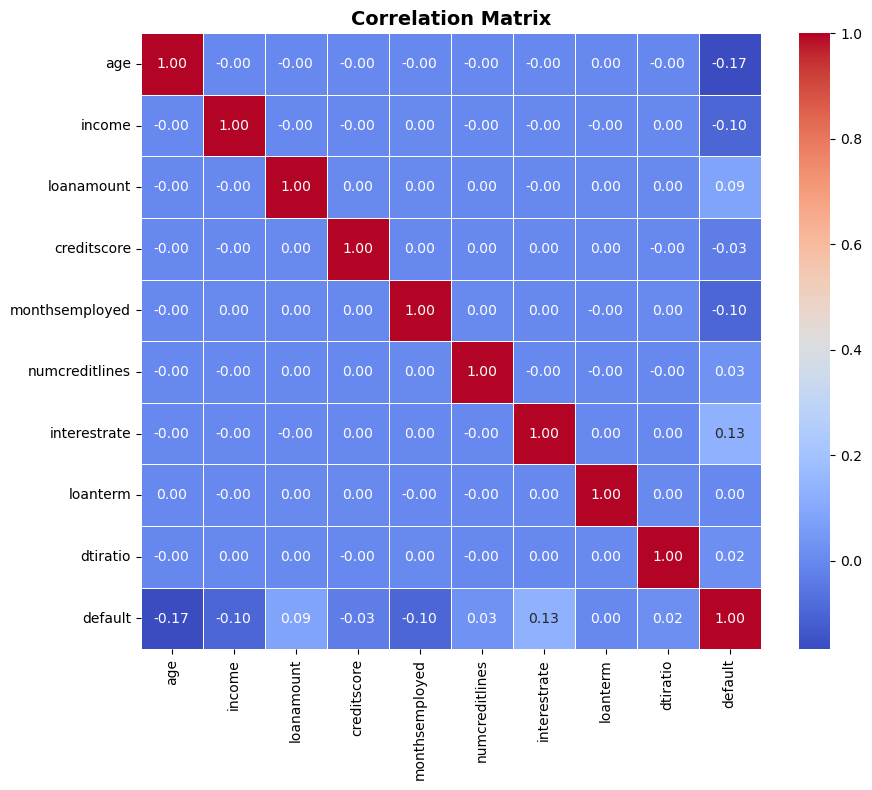

In [11]:
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title(
    "Correlation Matrix",
    fontsize=14,
    fontweight="bold"
)

plt.show()

# Statistical Interpretation

Examine the correlation coefficients to identify variables that have relatively stronger positive or negative relationships with the default variable.

A positive correlation indicates that as one variable increases, the other tends to increase.

A negative correlation indicates that as one variable increases, the other tends to decrease.

# Business Conclusion

The correlation matrix provides an overview of the relationships among numerical variables and helps identify factors that may be associated with loan default. These findings serve as an exploratory step and do not establish causal relationships.

# Chi-Square Test 1

Business Question

Does Employment Type Influence Loan Default?

Why This Matters

Employment status may influence a customer's ability to repay a loan. Identifying whether employment type is associated with loan default helps the bank improve its credit risk assessment process.

 Hypotheses
Null Hypothesis (H₀)

There is no statistically significant association between employment type and loan default.

Alternative Hypothesis (H₁)

There is a statistically significant association between employment type and loan default.

Why This Test?

Both variables are categorical.


Employment Type - Categorical , Loan Default - Binary Categorical

Therefore, the Chi-Square Test of Independence is the appropriate statistical test.

In [6]:
employment_table = pd.crosstab(
    df["employmenttype"],
    df["default"]
)

employment_table

default,0,1
employmenttype,,
Full-time,57632,6024
Part-time,56484,7677
Self-employed,56404,7302
Unemployed,55174,8650


In [7]:
chi2, p_value, dof, expected = chi2_contingency(employment_table)

print("Chi-square Statistic :", round(chi2, 4))
print("P-value :", round(p_value, 4))
print("Degrees of Freedom :", dof)

Chi-square Statistic : 529.7449
P-value : 0.0
Degrees of Freedom : 3


In [8]:
alpha = 0.05

if p_value < alpha:
    print("Reject the Null Hypothesis")
else:
    print("Fail to Reject the Null Hypothesis")

Reject the Null Hypothesis


Decision

Since the p-value (< 0.001) is less than the significance level (0.05), we reject the Null Hypothesis (H₀).

Statistical Interpretation

The Chi-Square Test indicates a statistically significant association between employment type and loan default. This means that the differences observed in loan default rates across employment categories are unlikely to have occurred due to random chance

Business Conclusion

Employment type is significantly associated with loan default. This suggests that employment status should be considered as one of the factors in the bank's credit risk assessment process. However, employment type should be evaluated together with other financial variables such as credit score, income, and debt-to-income ratio to support informed lending decisions.

# Key Takeaway
1) Employment type and loan default are statistically associated.
2) The relationship is statistically significant (p < 0.05).
3) Employment status should be included in the credit risk evaluation process.
4) The Chi-Square Test identifies an association, but it does not establish a cause-and-effect relationship.

# Chi-Square Test 2

Business Question

Does Education Level Influence Loan Default?

Why This Matters

Education level may influence employment opportunities, earning potential, and financial stability. The bank wants to determine whether education level is associated with loan default.

Hypotheses
Null Hypothesis (H₀)

There is no statistically significant association between education level and loan default.

Alternative Hypothesis (H₁)

There is a statistically significant association between education level and loan default.

Why This Test?

Both variables are categorical.


Education - Categorical , Loan Default - Binary Categorical

Therefore, the Chi-Square Test of Independence is the appropriate statistical test.

In [12]:
education_table = pd.crosstab(
    df["education"],
    df["default"]
)

education_table

default,0,1
education,,
Bachelor's,56577,7789
High School,55673,8230
Master's,56633,6908
PhD,56811,6726


In [13]:
chi2, p_value, dof, expected = chi2_contingency(education_table)

print("Chi-square Statistic:", round(chi2,4))
print("P-value:", p_value)
print("Degrees of Freedom:", dof)

Chi-square Statistic: 214.019
P-value: 3.9404864175508716e-46
Degrees of Freedom: 3


In [14]:
alpha = 0.05

if p_value < alpha:
    print("Reject the Null Hypothesis")
else:
    print("Fail to Reject the Null Hypothesis")

Reject the Null Hypothesis


Decision

Since the p-value (3.9404864175508716e-46) is less than the significance level (0.05), we reject the Null Hypothesis (H₀).

Statistical Interpretation

The Chi-Square Test indicates a statistically significant association between education and loan default. The observed differences in loan default across education categories are unlikely to have occurred due to random variation.

Business Conclusion

Education level is associated with loan default and may be considered as a supporting variable in the bank's credit risk assessment.

# Key Takeaway
1. Education and loan default are statistically associated.
2. Education should be used alongside other financial indicators.

# Chi-Square Test 3

Business Question

Does Loan Purpose Influence Loan Default?

Why This Matters

Different loan purposes may carry different levels of financial risk. Identifying whether loan purpose is associated with default helps the bank refine lending policies.

Hypotheses
Null Hypothesis (H₀)

There is no statistically significant association between loan purpose and loan default.

Alternative Hypothesis (H₁)

There is a statistically significant association between loan purpose and loan default.

Why This Test?

Both variables are categorical.


Loan Purpose - Categorical , 
Loan Default - Binary Categorical

Therefore, the Chi-Square Test of Independence is appropriate.

In [5]:
loanpurpose_table = pd.crosstab(
    df["loanpurpose"],
    df["default"]
)

loanpurpose_table

default,0,1
loanpurpose,,
Auto,44803,6041
Business,44975,6323
Education,44967,6038
Home,46037,5249
Other,44912,6002


In [6]:
chi2, p_value, dof, expected = chi2_contingency(loanpurpose_table)

print("Chi-square Statistic:", round(chi2,4))
print("P-value:", p_value)
print("Degrees of Freedom:", dof)

Chi-square Statistic: 127.9342
P-value: 1.0767865809403042e-26
Degrees of Freedom: 4


In [7]:
alpha = 0.05

if p_value < alpha:
    print("Reject the Null Hypothesis")
else:
    print("Fail to Reject the Null Hypothesis")

Reject the Null Hypothesis


Decision

Since the p-value (1.0767865809403042e-26) is less than the significance level (0.05), we reject the Null Hypothesis (H₀).

Statistical Interpretation

The Chi-Square Test indicates a statistically significant association between loanpurpose and loan default. The observed differences in loan default across laonpurpose are unlikely to have occurred due to random variation.

Business Conclusion

Loanpurpose is associated with loan default and should be considered when evaluating credit risk and reviewing lending policies.

# Key Takeaway
1. Loan purpose and default are statistically associated.
2. Loan purpose can be used as a supporting risk factor.

# Chi-Square Test 4

Business Question

Does Marital Status Influence Loan Default?

Why This Matters

Marital status may be associated with differences in financial responsibilities and repayment behavior. The bank wants to determine whether marital status is related to loan default.

Hypotheses
Null Hypothesis (H₀)

There is no statistically significant association between marital status and loan default.

Alternative Hypothesis (H₁)

There is a statistically significant association between marital status and loan default.

In [9]:
marital_table = pd.crosstab(
    df["maritalstatus"],
    df["default"]
)

marital_table

default,0,1
maritalstatus,,
Divorced,74376,10657
Married,76433,8869
Single,74885,10127


In [10]:
chi2, p_value, dof, expected = chi2_contingency(marital_table)

print("Chi-square Statistic:", round(chi2,4))
print("P-value:", p_value)
print("Degrees of Freedom:", dof)

Chi-square Statistic: 200.3611
P-value: 3.105504830442356e-44
Degrees of Freedom: 2


In [12]:
alpha = 0.05

if p_value < alpha:
    print("Reject the Null Hypothesis")
else:
    print("Fail to Reject the Null Hypothesis")

Reject the Null Hypothesis


Decision

Since the p-value (3.105504830442356e-44) is less than the significance level (0.05), we reject the Null Hypothesis (H₀).

Statistical Interpretation

The Chi-Square Test indicates a statistically significant association between maritalstatus and loan default. The observed differences in loan default across maritalstatus are unlikely to have occurred due to random variation.

Business Conclusion

Maritalstatus is associated with loan default and may be considered as a supporting factor during credit risk evaluation.

# Key Takeaway
1. Marital status and default are statistically associated.
2. Marital status should be interpreted alongside other borrower characteristics.

In [13]:
def run_chi_square(df, feature, target="default"):
    """
    Performs Chi-Square Test of Independence
    """

    from scipy.stats import chi2_contingency

    contingency_table = pd.crosstab(df[feature], df[target])

    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    print("="*60)
    print(f"Feature: {feature}")
    print("="*60)

    print("\nContingency Table")
    print(contingency_table)

    print("\nChi-square Statistic :", round(chi2,4))
    print("P-value :", p_value)
    print("Degrees of Freedom :", dof)

    alpha = 0.05

    if p_value < alpha:
        print("\nDecision : Reject Null Hypothesis")
        print("Conclusion : Significant Association Exists")
    else:
        print("\nDecision : Fail to Reject Null Hypothesis")
        print("Conclusion : No Significant Association")

    print("="*60)

# Chi-Square Test 5

Business Question

Does Mortgage Status Influence Loan Default?

Why This Matters

Mortgage ownership may reflect a customer's financial obligations and repayment capacity. The bank wants to determine whether mortgage status is associated with loan default.

Hypotheses

H₀

There is no statistically significant association between mortgage status and loan default.

H₁

There is a statistically significant association between mortgage status and loan default.

In [15]:
run_chi_square(df, "hasmortgage")

Feature: hasmortgage

Contingency Table
default           0      1
hasmortgage               
No           111909  15761
Yes          113785  13892

Chi-square Statistic : 133.252
P-value : 7.96338322455275e-31
Degrees of Freedom : 1

Decision : Reject Null Hypothesis
Conclusion : Significant Association Exists


Decision

Since the p-value (7.96338322455275e-31) is less than the significance level (0.05), we reject the Null Hypothesis (H₀).

Statistical Interpretation

The Chi-Square Test indicates a statistically significant association between hasmortgage and loan default. The observed differences in loan default across Mortgage status are unlikely to have occurred due to random variation.

Business Decision

Mortgage status is statistically associated with loan default and should be considered as one of the variables during credit risk evaluation.

# Chi-Square Test 6

Business Question

Does Having a Co-signer Influence Loan Default?

Why This Matters

A co-signer provides additional financial security for the bank. This analysis determines whether having a co-signer is associated with loan default.

Hypotheses

H₀

There is no statistically significant association between co-signer status and loan default.

H₁

There is a statistically significant association between co-signer status and loan default.

In [17]:
run_chi_square(df, "hascosigner")

Feature: hascosigner

Contingency Table
default           0      1
hascosigner               
No           111223  16423
Yes          114471  13230

Chi-square Statistic : 390.305
P-value : 7.103434211754059e-87
Degrees of Freedom : 1

Decision : Reject Null Hypothesis
Conclusion : Significant Association Exists


Decision

Since the p-value ( 7.103434211754059e-87) is less than the significance level (0.05), we reject the Null Hypothesis (H₀).

Statistical Interpretation

The Chi-Square Test indicates a statistically significant association between hascosigner and loan default. The observed differences in loan default across Cosigner status are unlikely to have occurred due to random variation.

Business Decision

Cosigner status is statistically associated with loan default and can be considered as an additional factor during the loan approval process.

# Independent Samples t-Test

# Reusable Independent t-Test Function

In [20]:
def run_ttest(df, feature, target="default"):
    """
    Performs Independent Samples t-Test
    """

    from scipy.stats import ttest_ind

    group1 = df[df[target] == 1][feature]
    group2 = df[df[target] == 0][feature]

    t_stat, p_value = ttest_ind(
        group1,
        group2,
        equal_var=False
    )

    print("="*60)
    print(f"Feature : {feature}")
    print("="*60)

    print(f"Average (Default) : {group1.mean():.2f}")
    print(f"Average (No Default) : {group2.mean():.2f}")

    print(f"\nT-statistic : {t_stat:.4f}")
    print(f"P-value : {p_value:.6f}")

    alpha = 0.05

    if p_value < alpha:
        print("\nDecision : Reject Null Hypothesis")
        print("Conclusion : Significant Difference Exists")
    else:
        print("\nDecision : Fail to Reject Null Hypothesis")
        print("Conclusion : No Significant Difference")

    print("="*60)

Business Question

Does Income Differ Between Defaulted and Non-Defaulted Customers?

In [21]:
run_ttest(df, "income")

Feature : income
Average (Default) : 71844.72
Average (No Default) : 83899.17

T-statistic : -48.1549
P-value : 0.000000

Decision : Reject Null Hypothesis
Conclusion : Significant Difference Exists


Statistical Interpretation

The Independent Samples t-Test indicates a statistically significant association between income and loan default. The observed differences in loan default across income are unlikely to have occurred due to random variation.

Business Conclusion

The average income differs significantly between defaulted and non-defaulted customers. Income should be considered as one of the variables during loan evaluation.

Business Question

Does Credit Score Differ Between Defaulted and Non-Defaulted Customers?

In [22]:
run_ttest(df, "creditscore")

Feature : creditscore
Average (Default) : 559.29
Average (No Default) : 576.23

T-statistic : -17.3024
P-value : 0.000000

Decision : Reject Null Hypothesis
Conclusion : Significant Difference Exists


Business Conclusion

The creditscore differs significantly between defaulted and non-defaulted customers. Creditscore should be considered as one of the variables during loan evaluation.

Business Question

Does Loan Amount Differ Between Defaulted and Non-Defaulted Customers?

In [23]:
run_ttest(df, "loanamount")

Feature : loanamount
Average (Default) : 144515.31
Average (No Default) : 125353.66

T-statistic : 44.5176
P-value : 0.000000

Decision : Reject Null Hypothesis
Conclusion : Significant Difference Exists


Business Conclusion

The loanamount differs significantly between defaulted and non-defaulted customers. Loan Amount should be considered as one of the variables during loan evaluation.

Business Question

Does Interest Rate Differ Between Defaulted and Non-Defaulted Customers?

In [24]:
run_ttest(df,"interestrate")

Feature : interestrate
Average (Default) : 15.90
Average (No Default) : 13.18

T-statistic : 69.2734
P-value : 0.000000

Decision : Reject Null Hypothesis
Conclusion : Significant Difference Exists


Business Conclusion

The interestrate differs significantly between defaulted and non-defaulted customers. Interest Rate should be considered as one of the variables during loan evaluation.

Business Question

Does Debt-to-Income Ratio Differ Between Defaulted and Non-Defaulted Customers?

In [25]:
run_ttest(df, "dtiratio")

Feature : dtiratio
Average (Default) : 0.51
Average (No Default) : 0.50

T-statistic : 9.7851
P-value : 0.000000

Decision : Reject Null Hypothesis
Conclusion : Significant Difference Exists


Business Conclusion

The dtiratio differs significantly between defaulted and non-defaulted customers. DTI Ratio should be considered as one of the variables during loan evaluation.

Business Question

Does Months Employed Differ Between Defaulted and Non-Defaulted Customers?

In [26]:
run_ttest(df, "monthsemployed")

Feature : monthsemployed
Average (Default) : 50.24
Average (No Default) : 60.76

T-statistic : -50.1927
P-value : 0.000000

Decision : Reject Null Hypothesis
Conclusion : Significant Difference Exists


Business Conclusion

The monthsemoloyed differs significantly between defaulted and non-defaulted customers. Months Employed should be considered as one of the variables during loan evaluation.

## Executive Summary

This notebook applied statistical hypothesis testing to validate the patterns identified during exploratory data analysis. Correlation analysis, Chi-Square Tests of Independence, and Independent Samples t-Tests were performed to determine whether customer characteristics and loan attributes were significantly associated with loan default.

The results provide statistical evidence to support business recommendations and strengthen confidence in the analytical findings.

## Key Statistical Findings

- Employment type was statistically significant.
- Education level was statistically significant.
- Loan purpose was statistically significant.
- Marital status was statistically significant.
- Mortgage status was statistically significant.
- Co-signer status was statistically significant.


- Average income differed significantly.
- Average credit score differed significantly.
- Average loan amount differed significantly.
- Average interest rate differed significantly.
- Average debt-to-income ratio differed significantly.
- Average months employed differed significantly.

## Business Recommendations

Based on the statistical analysis, the following recommendations are proposed:

1. Continue incorporating employment type into the credit risk assessment process if it shows a statistically significant association with loan default.

2. Consider customer education, loan purpose, mortgage status, and co-signer information as supporting variables where statistically significant.

3. Give greater attention to numerical variables that show significant differences between defaulted and non-defaulted customers, such as income, credit score, or debt-to-income ratio.

4. Use statistically significant variables to support future credit risk models and improve lending decisions.

5. Combine statistical findings with business expertise and regulatory guidelines to ensure balanced and fair lending practices.

## Conclusion

Statistical hypothesis testing confirmed which customer characteristics and loan attributes are significantly associated with loan default. These findings strengthen the conclusions drawn during exploratory data analysis and provide evidence-based insights for improving credit risk assessment.

The statistically significant variables identified in this notebook can be used to support business decision-making, SQL-based reporting, interactive dashboard development, and future predictive modeling initiatives.